In [1]:
from functions import generate_H, generate_D, generate_F, compute_costs, accumulate_traces, pick_direction, gradient_analysis, compute_ac
import numpy as np
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.pyplot as plt

In [2]:
B = 36 # Number of visual bins, evenly distributed around the agent
scale = 50  # length of one side of the H map in meters
resolution = 10 # simulated points per meter 
sigma = 35 # major slope in degrees
noise_scale = 0 # Noise applied to H(x,y,t=0)

# Generate H 
x, y, H0, size, offsets = generate_H(scale, resolution, sigma, noise_scale, plot=False)

# # Randomly initiate agents 
# N = 1 # number of agents 
# agent_pos = size*np.random.rand(2,N)

# # Critical parameters
# beta = 50 # Energy landscape sensitivity
# alpha = -0.1 #The depth of the agent's footprint. How quickly the environment erodes. 
# delta = 0.5*resolution #Footprint interval.
# eta = 0.5*resolution #resolution
# L = 10*resolution

# # Generate the footprint map
# r_F = 1*resolution
# F = generate_F(r_F) #radius*2)

# # Initialize the depletion layer
# R = np.ones([size, size])

# # Generate the depletion map
# r_D = 2*resolution
# D = generate_D(r_D) #radius*2)
# gamma = -1 # resource depletion strength
# mu = 0.1 # resource regrowth rate
# w_v = 8.25 # vertical motion cost scalar
# w_h = 0.95 # horizontal motion cost scalar 

# max_steps = 50000
# num_steps = 0
# plt_interval = max_steps//20
# max_erosion = resolution*1.5
# abs_erosion = 0 
# save_interval = 10
# abs_erosion = 0 
# frame = 0

# # Create the enviroment for modification (gradient_layer)
# H = H0.copy()

omega = 2*resolution # gradient analysis window size 

Let's try again but make the ratios correct... 

In [3]:
# # size is fixed
# Ls = np.flip(size/np.arange(1, 21)) # results in a linear distribution of revisit times
# mus = np.flip(1/np.arange(1,21)) # results in a linear distribution of recovery times

# # save H and each resultant terrain for post-hoc analysis 
# np.save(f'depletion_regrowth_2/H0.npy', H0)

# for beta in [50]:
#     for L in Ls: 
#         for mu in mus:  
#             # Skip if there is no self-interaction via the resource layer
#             if (size/L) > (1/mu):
#                 np.save(f'depletion_regrowth_2/H_{L}_{mu}.npy', H0)
#                 np.save(f'depletion_regrowth_2/steps_{L}_{mu}.npy', 0)    
#                 continue
            
#             # reinitialize necessary parameters
#             num_steps = 0
#             abs_erosion = 0
#             H = H0.copy()
#             R = np.ones([size, size])
#             agent_pos = size*np.random.rand(2,N)
            
#             while (num_steps <= max_steps) and (abs_erosion <= max_erosion):

#                 R += mu
#                 R[R > 1] = 1

#                 for j in range(N): 
#                     # Compute costs along potential paths     
#                     angles_mesh, radial_mesh, gradient, depletion = compute_costs(agent_pos[:,j], B, delta, L, H, R, size, offsets, resolution)
#                     # Pick a new direction and update agent position
#                     agent_pos[:,j], line, angle, entropy = pick_direction(agent_pos[:,j], beta, angles_mesh, radial_mesh, gradient, depletion, w_h, w_v, delta, size)
#                     # Update gradient layer 
#                     H, _ = accumulate_traces(H, F, line, alpha, eta)    
#                     deviation = H0 - H
#                     abs_erosion = np.max(deviation) - np.min(deviation)
                    
#                     # Update resource layer
#                     R, _ = accumulate_traces(R, D, line, gamma, 0)
#                     R[R < 0] = 0
                    
#                 num_steps += 1
            
#             np.save(f'SIfig04/H_{L}_{mu}.npy', H)
#             np.save(f'SIfig04/steps_{L}_{mu}.npy', num_steps)
            
#             # Plot an update of terrain and resource erosion
#             fig, axs = plt.subplots(ncols=2, figsize=(5,10))
#             axs[0].imshow(deviation - np.min(deviation), origin='lower', cmap='jet', extent=(0, scale, 0, scale))
#             axs[0].set_title(f't={num_steps}, beta={beta}, L={L}')
#             axs[1].imshow(R, origin='lower', cmap='Greens', extent=(0, scale, 0, scale))
#             axs[1].set_title(f'mu={mu}, sigma={sigma}, N={N}')
#             plt.show()
        

In [4]:
Ls = np.flip(size/np.arange(1, 21)) # results in a linear distribution of revisit times
mus = np.flip(1/np.arange(1,21)) # results in a linear distribution of recovery times
H0 = np.load('SIfig04/H0.npy')

paths = [[np.zeros(np.shape(H0)[0]-1), np.arange(0, np.shape(H0)[0]-1)],
         [100*np.ones(np.shape(H0)[0]-1), np.arange(0, np.shape(H0)[0]-1)],
         [200*np.ones(np.shape(H0)[0]-1), np.arange(0, np.shape(H0)[0]-1)],
         [300*np.ones(np.shape(H0)[0]-1), np.arange(0, np.shape(H0)[0]-1)],
         [400*np.ones(np.shape(H0)[0]-1), np.arange(0, np.shape(H0)[0]-1)]]

img = np.zeros((len(Ls), len(mus)))
img_corr = img.copy()
time_ratio = img.copy()
#noise = np.random.rand(size, size)

for i, L in enumerate(Ls):
    for j, mu in enumerate(mus):
        H = np.load(f'SIfig04/H_{L}_{mu}.npy')
        deviation = H0 - H
        #deviation += noise*0.01
        abs_erosion = np.max(deviation) - np.min(deviation)
        _, mean_gradient, mean_coherence = gradient_analysis(deviation, omega)
        corr, prominence, lag = compute_ac(deviation, paths, plot=False)  
        img_corr[i,j] = corr
        img[i, j] = mean_coherence
        time_ratio[i,j] = (size/L) / (1/mu)


/home/benix/Workspace/terracettes/functions.py:479: RuntimeWarning: invalid value encountered in divide
  coherence = np.where(G_xx + G_yy == 0, 0, np.sqrt(((G_xx - G_yy)**2) + (4*(G_xy**2))) / (G_xx + G_yy))
/home/benix/Workspace/terracettes/functions.py:481: RuntimeWarning: invalid value encountered in divide
  theta = np.arctan(Vj/Vi)%(np.pi)
/home/benix/Workspace/terracettes/terra_venv/lib/python3.10/site-packages/statsmodels/tsa/stattools.py:702: RuntimeWarning: invalid value encountered in divide
  acf = avf[: nlags + 1] / avf[0]


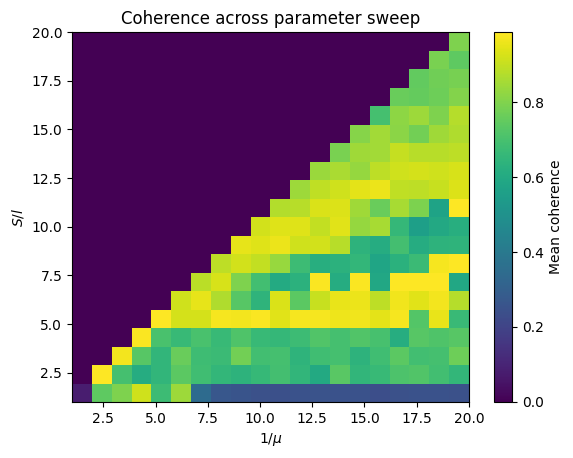

In [5]:
extent = [1/mus.max(), 1/mus.min(), size/Ls.max(), size/Ls.min()]
img_rot = np.rot90(img, 2)   # rotate 180 degrees
plt.imshow(img_rot, origin='lower', aspect='auto', extent=extent)
plt.colorbar(label="Mean coherence")

plt.xlabel(r'$1/\mu$')
plt.ylabel(r'$S/l$')
plt.title("Coherence across parameter sweep")

plt.show()

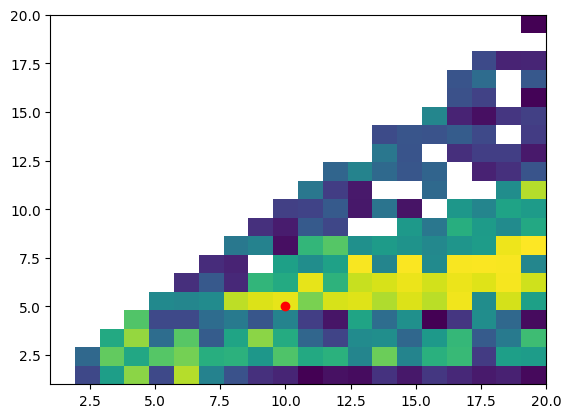

In [6]:
extent = [1/mus.max(), 1/mus.min(), size/Ls.max(), size/Ls.min()]
plt.imshow(np.rot90(img_corr, 2), origin='lower', aspect='auto', extent=extent, interpolation='nearest')
plt.scatter(10, 5, c='r')

In [7]:
# Run the autocorrelation analysis on each surface
xs, ys, corrs, cohs, steps = [], [], [], [], []

noise = np.random.rand(size,size)

for i, L in enumerate(Ls):
    for j, mu in enumerate(mus):
        H = np.load(f'SIfig04/H_{L}_{mu}.npy')
        deviation = H0 - H
        deviation += noise
        step = np.load(f'SIfig04/steps_{L}_{mu}.npy')

        #if ((size/L) > (1/mu)) or (step > 50000):
        if (size/L) > (1/mu):
            corr = np.nan
            mean_coherence = np.nan
        else: 
            abs_erosion = np.max(deviation) - np.min(deviation)
            _, mean_gradient, mean_coherence = gradient_analysis(deviation, omega)
            corr, prominence, lag = compute_ac(deviation, paths) 
            if np.isnan(corr):
                corr = 0
        
        xs.append(1/mu)
        ys.append(size/L)
        steps.append(step)
        corrs.append(corr)  # size
        cohs.append(mean_coherence)   # color

xs, ys = np.array(xs), np.array(ys)
corrs   = np.array(corrs)
cohs   = np.array(cohs)
steps = np.array(steps)

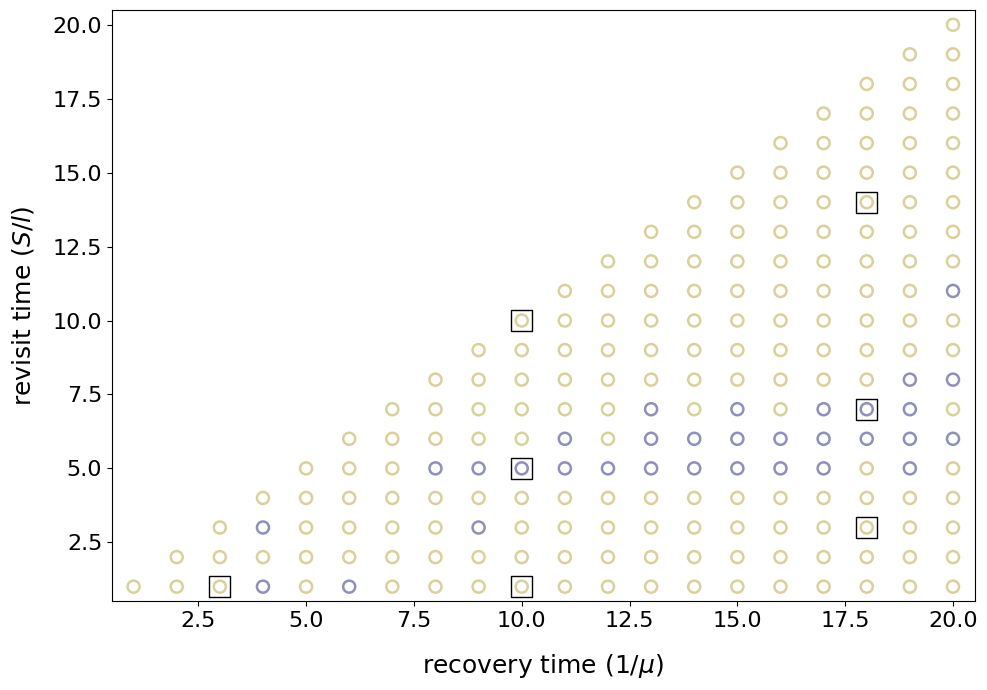

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm
from matplotlib.cm import ScalarMappable

# xs, ys, corrs already defined (corrs in [0,1] with possible NaNs)

# 1) Discrete bins and colors
bounds = [0.0, 0.75, 1.0]                     # thresholds
cmap   = ListedColormap(["#b5a433", "#1f217d"])
norm   = BoundaryNorm(bounds, cmap.N, clip=True)

# 2) Map your values -> RGBA for edges
corrs_arr = np.array(corrs, dtype=float)
edge_cols = cmap(norm(corrs_arr))                 # RGBA for each point

# Handle NaNs explicitly (pick any color you like for NaNs)
nan_mask = np.isnan(corrs_arr)
edge_cols[nan_mask] = (0.75, 0.75, 0.75, 1.0)     # light gray for NaNs

# 3) Plot with transparent faces and colored edges
fig, ax = plt.subplots(figsize=(10, 7))
ax.scatter(xs[~nan_mask], ys[~nan_mask],
           s=75,
           facecolors='none',                     # transparent fill
           edgecolors=edge_cols[~nan_mask],                 # colored ring
           linewidths=1.8,                       # make the ring visible
           marker='o',                           # or 's' for square outline
           alpha=0.5)
# (Optional) plot NaNs with a distinct marker as well:
# ax.scatter(xs[nan_mask], ys[nan_mask], s=60, facecolors='none',
#            edgecolors='0.5', linewidths=1.2, marker='x')

# 4) Add a matching discrete colorbar via a ScalarMappable
sm = ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])                                  # required for some MPL versions
tick_locs   = [(bounds[i]+bounds[i+1])/2 for i in range(len(bounds)-1)]
tick_labels = [f"{bounds[i]:.1f}–{bounds[i+1]:.1f}" for i in range(len(bounds)-1)]
# cbar = fig.colorbar(sm, ax=ax, boundaries=bounds, ticks=tick_locs, pad=0.02, aspect=30)
# cbar.ax.set_yticklabels(tick_labels)
# cbar.set_label("R (edge color)", rotation=0, labelpad=10)

ax.set_xlabel(r'recovery time ($1/\mu$)', fontsize=18, labelpad=15)
ax.set_ylabel(r'revisit time ($S/l$)', fontsize=18, labelpad=12)
ax.set_xlim(min(xs)-0.5, max(xs)+0.5)
ax.set_ylim(min(ys)-0.5, max(ys)+0.5)
ax.set_axisbelow(True)
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
plt.tight_layout()
tempx, tempy = [3, 10, 10, 10, 18, 18, 18], [1, 1, 5, 10, 3, 7, 14]
plt.scatter(tempx, tempy, marker='s', facecolors='None', edgecolors='k', s=230, lw=1)
plt.savefig('Figures/depletion_regrowth_1.png', transparent=True, bbox_inches='tight')

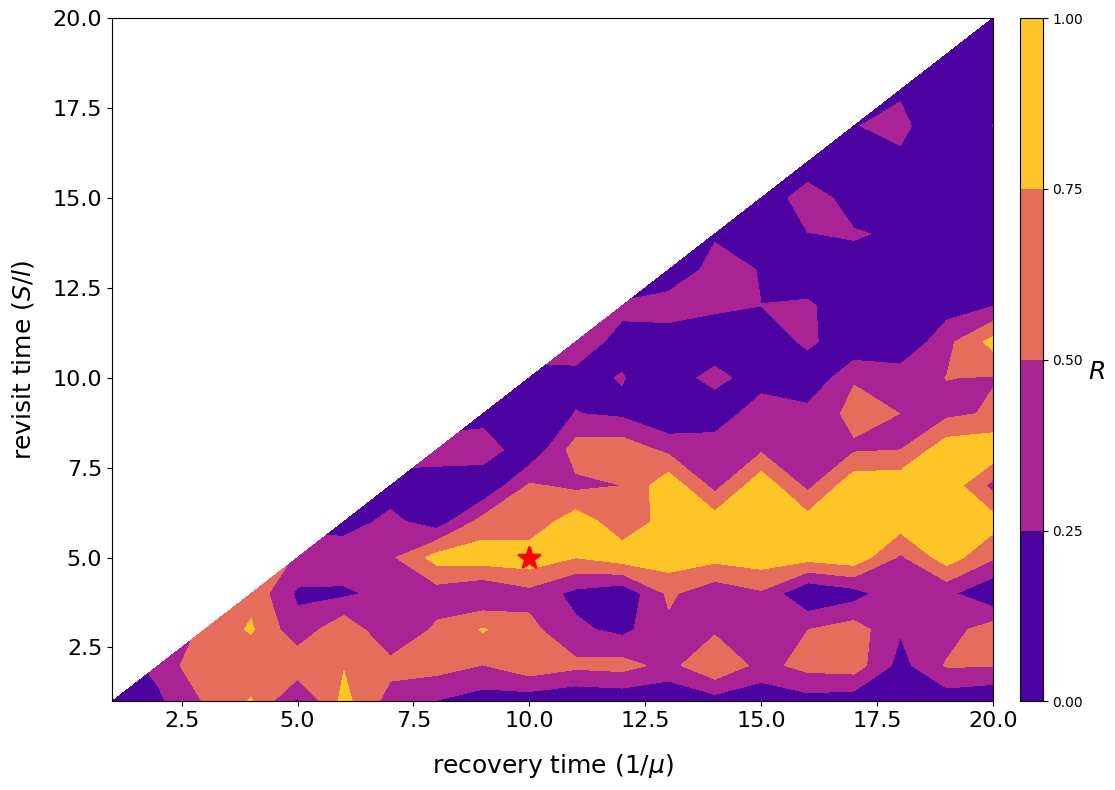

In [9]:
import numpy as np
import matplotlib.pyplot as plt

# xs, ys, corrs already built as in your code
Llen, Mlen = len(Ls), len(mus)

# reshape to 2D grid (rows: Ls -> S/L; cols: mus -> 1/mu)
Z = corrs.reshape(Llen, Mlen)
Xvec = 1.0/np.asarray(mus)   # x coordinates per column
Yvec = size/np.asarray(Ls)   # y coordinates per row

# (optional) sort so axes increase left→right, bottom→top
x_idx = np.argsort(Xvec)
y_idx = np.argsort(Yvec)
Xvec  = Xvec[x_idx]
Yvec  = Yvec[y_idx]
Z     = Z[np.ix_(y_idx, x_idx)]

# mask NaNs so they don't fill
Z = np.ma.masked_invalid(Z)

X, Y = np.meshgrid(Xvec, Yvec)

fig, ax = plt.subplots(figsize=(12, 8))

# --- continuous contourf ---
levels = 3  # number of filled levels; increase for smoother look
cf = ax.contourf(X, Y, Z, levels=levels, cmap='plasma')  # try 'cividis', 'magma', 'plasma'

# colorbar
cbar = fig.colorbar(cf, ax=ax, pad=0.025, aspect=30)
cbar.set_label(r'$R$', rotation=0, labelpad=10, fontsize=18)

# highlight box, axes labels
ax.scatter(10, 5, marker='*', facecolors='r', s=250, lw=2)
ax.set_xlim(Xvec.min(), Xvec.max())
ax.set_ylim(Yvec.min(), Yvec.max())

ax.set_xlabel(r'recovery time ($1/\mu$)', fontsize=18, labelpad=15)
ax.set_ylabel(r'revisit time ($S/l$)', fontsize=18, labelpad=12)
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)

plt.tight_layout()

plt.savefig('Figures/depletion_regrowth_2.png', transparent=True, bbox_inches='tight')


Generate some snapshots

3.0
1.0


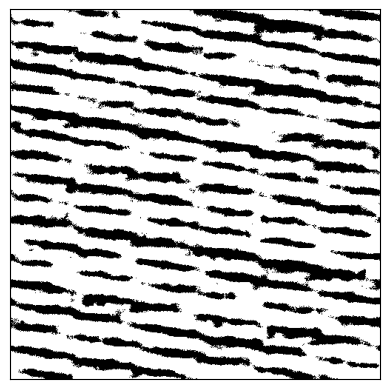

10.0
1.0


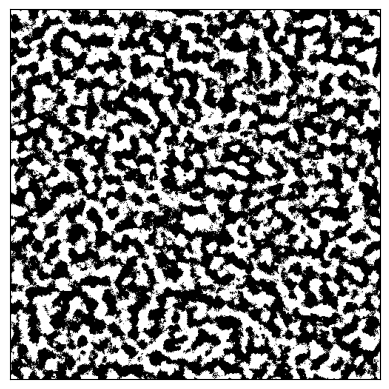

10.0
5.0


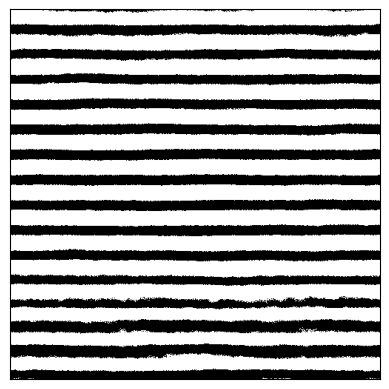

10.0
10.0


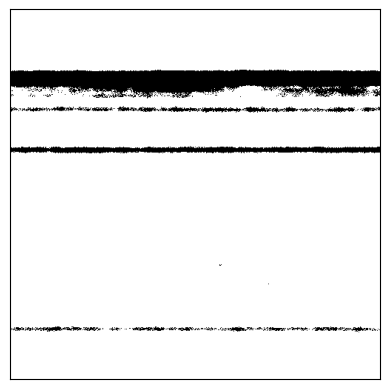

18.0
3.0


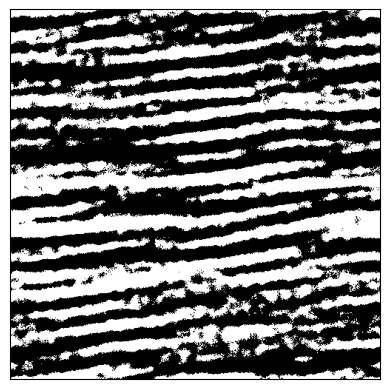

18.0
7.0


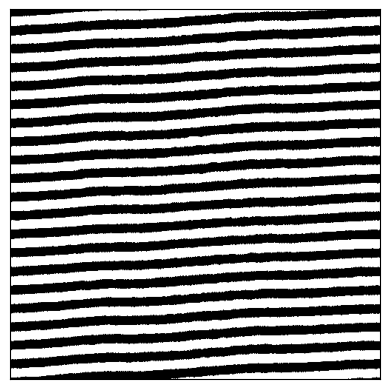

18.0
14.0


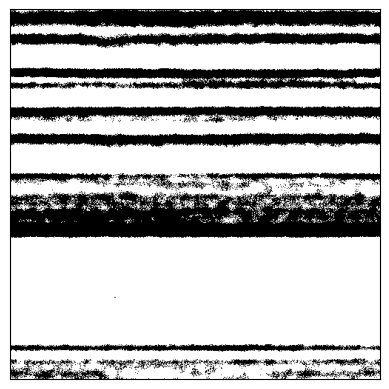

In [10]:
tempx, tempy = [3, 10, 10, 10, 18, 18, 18], [1, 1, 5, 10, 3, 7, 14]

for i in range(len(tempx)):
    L = Ls[20 - tempy[i]]
    mu = mus[20 - tempx[i]]
    
    print(1/mu)
    print(size/L)

    deviation = H0 - np.load(f'SIfig04/H_{L}_{mu}.npy') + noise
    deviation = deviation - np.min(deviation)
    temp = np.max(deviation)/2
    mask = deviation > temp

    temp = deviation.copy()
    temp[mask] = 1
    temp[~mask] = 0
    plt.imshow(temp, origin='lower', cmap='binary')
    plt.xticks([])
    plt.yticks([])
    plt.show()